# Capítulo 20 — Soluções dos exercícios complementares

**Curso de Meteorologia Prática** — baseado em R. Stull, *Practical Meteorology* (CC BY-NC-SA 4.0).

> **Para o professor.** Soluções dos teóricos **T1–T5** e numéricos **N1–N4** do Cap. 20. Não distribuir antes da entrega.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit
import sys; sys.path.append('../comum')
from estilo_meteo import aplicar_estilo, CORES
aplicar_estilo()

sig, rho, beta = 10.0, 28.0, 8/3
def lorenz(t, s):
    X, Y, Z = s
    return [sig*(Y - X), X*(rho - Z) - Y, X*Y - beta*Z]

## T1 — CFL por von Neumann

In [2]:
# upwind: phi_j^{n+1} = phi_j - C(phi_j - phi_{j-1}); modo phi_j = g^n e^{ikjdx}
C_, th = sp.symbols('C theta', real=True)
gfac = 1 - C_*(1 - sp.exp(-sp.I*th))
mod2 = sp.simplify(sp.expand(sp.Abs(gfac)**2, complex=True))
mod2 = sp.simplify(sp.re(gfac)**2 + sp.im(gfac)**2)
display(sp.Eq(sp.Symbol('|g|^2'), sp.simplify(sp.trigsimp(mod2))))
print('|g|² = 1 - 2C(1-C)(1-cos θ): |g| ≤ 1 para todo θ exige 0 ≤ C ≤ 1. ∎')
print()
print('Interpretacao fisica: em um passo de tempo a informacao real anda U·dt;')
print('o esquema so "enxerga" a celula vizinha (dx). Se U·dt > dx, a fisica')
print('ultrapassa o estencil e o esquema inventa — e explode.')

Eq(|g|^2, C**2*sin(theta)**2 + (C*(cos(theta) - 1) + 1)**2)

|g|² = 1 - 2C(1-C)(1-cos θ): |g| ≤ 1 para todo θ exige 0 ≤ C ≤ 1. ∎

Interpretacao fisica: em um passo de tempo a informacao real anda U·dt;
o esquema so "enxerga" a celula vizinha (dx). Se U·dt > dx, a fisica
ultrapassa o estencil e o esquema inventa — e explode.


## T2 — A difusão escondida no upwind

In [3]:
# expansão de Taylor da equação discreta -> equação modificada
x, t, dx, dt, U = sp.symbols('x t Delta_x Delta_t U', positive=True)
phi = sp.Function('phi')
lhs = (phi(x, t + dt) - phi(x, t))/dt + U*(phi(x, t) - phi(x - dx, t))/dx
serie = sp.expand(lhs.series(dt, 0, 2).removeO().series(dx, 0, 3).removeO())
print('equação modificada (termos até 2ª ordem):')
display(sp.simplify(serie))
print()
print('=> phi_t + U phi_x = (U dx/2)(1 - C) phi_xx + O(dx²): o upwind resolve')
print('a advecção MAIS uma difusao com K_num = U·dx·(1-C)/2. Com U = 10 m/s,')
print(f'dx = 10 km, C = 0,5: K_num = {10*10e3*0.5/2:.0f} m²/s — difusao gigante,')
print('e por isso frentes derretem em modelos de baixa ordem (Cap. 12/Cap. 3).')

equação modificada (termos até 2ª ordem):


Delta_t*Derivative(phi(x, t), (t, 2))/2 + Delta_x**2*U*Derivative(phi(x, t), (x, 3))/6 - Delta_x*U*Derivative(phi(x, t), (x, 2))/2 + U*Derivative(phi(x, t), x) + Derivative(phi(x, t), t)


=> phi_t + U phi_x = (U dx/2)(1 - C) phi_xx + O(dx²): o upwind resolve
a advecção MAIS uma difusao com K_num = U·dx·(1-C)/2. Com U = 10 m/s,
dx = 10 km, C = 0,5: K_num = 25000 m²/s — difusao gigante,
e por isso frentes derretem em modelos de baixa ordem (Cap. 12/Cap. 3).


## T3 — Lyapunov e o limite de previsibilidade

**Solução.** Erros crescem como $\epsilon(t) = \epsilon_0 e^{\lambda t}$ enquanto pequenos. O horizonte é quando $\epsilon$ atinge a saturação $E$ (o tamanho do atrator):
$$t_{max} = \frac{1}{\lambda}\ln\frac{E}{\epsilon_0}.$$
A dependência é **logarítmica** em $\epsilon_0$: reduzir o erro inicial 10× (bilhões em satélites!) compra apenas $\ln 10/\lambda \approx$ 2–3 dias. Com dobra de ~2 dias na atmosfera, o teto prático é ~2 semanas — não por falta de computador, mas por estrutura do sistema. É a resposta de Lorenz à pergunta de Von Neumann. ∎

## T4 — O ganho ótimo

In [4]:
K, sb, so = sp.symbols('K sigma_b sigma_o', positive=True)
# x_a = x_b + K(y - x_b); erros independentes:
var_a = (1 - K)**2*sb**2 + K**2*so**2
K_opt = sp.solve(sp.diff(var_a, K), K)[0]
display(sp.Eq(sp.Symbol('K^*'), sp.simplify(K_opt)))
var_min = sp.simplify(var_a.subs(K, K_opt))
display(sp.Eq(sp.Symbol('sigma_a^2'), var_min))
print('K* = σb²/(σb²+σo²) e σa⁻² = σb⁻² + σo⁻²: as precisões SOMAM —')
print('a analise e melhor que modelo E observacao. E a mesma formula do filtro')
print('de Kalman, dos minimos quadrados e da media ponderada por 1/σ² do lab.')

Eq(K^*, sigma_b**2/(sigma_b**2 + sigma_o**2))

Eq(sigma_a^2, sigma_b**2*sigma_o**2/(sigma_b**2 + sigma_o**2))

K* = σb²/(σb²+σo²) e σa⁻² = σb⁻² + σo⁻²: as precisões SOMAM —
a analise e melhor que modelo E observacao. E a mesma formula do filtro
de Kalman, dos minimos quadrados e da media ponderada por 1/σ² do lab.


## T5 — Resolução efetiva

**Solução.** Uma onda de comprimento $\lambda$ é amostrada por $\lambda/\Delta x$ pontos. Com 2 pontos (Nyquist) a onda existe mas sua advecção é péssima: o erro de fase dos esquemas cresce brutalmente para $\lambda < 6$–$8\Delta x$ (no leapfrog, a onda $2\Delta x$ tem velocidade de grupo NEGATIVA!). Por isso a **resolução efetiva** de um modelo é ~7$\Delta x$: um modelo de "10 km" simula bem fenômenos de ≳70 km — cumulus individuais (~1–10 km) ficam fora e precisam de **parametrização**, com a turbulência (Cap. 18), a radiação (Cap. 2) e a microfísica (Cap. 7). ∎

---
## N1 — Medindo a difusão numérica

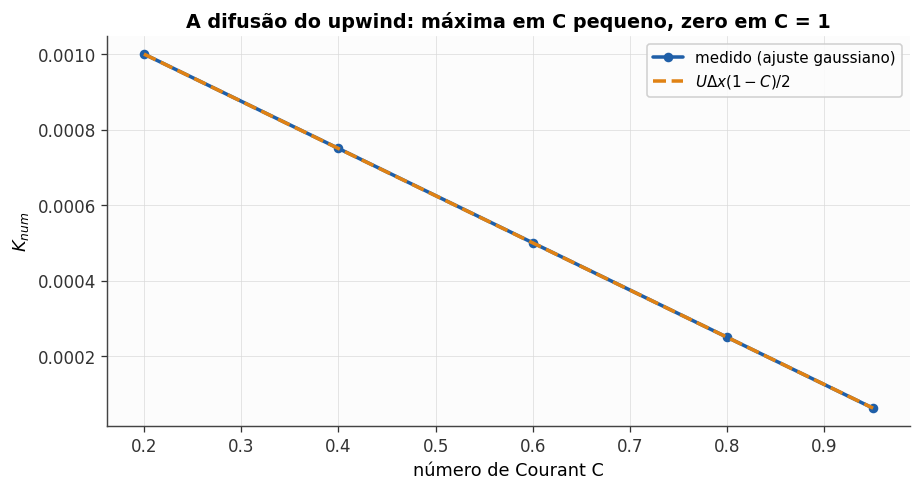

em C = 1 o upwind e EXATO (a informacao pula exatamente uma celula);
quanto menor o C, mais interpolacao e mais derretimento — teoria confirmada.


In [5]:
nx, L, U = 400, 1.0, 1.0
dx = L/nx
x = np.arange(nx)*dx
s0 = 0.03
phi0 = np.exp(-((x - 0.3)/s0)**2/1)

def upwind_volta(C):
    dt = C*dx/U
    nt = int(round(L/(U*dt)))
    phi = phi0.copy()
    for _ in range(nt):
        phi = phi - C*(phi - np.roll(phi, 1))
    return phi, nt*dt

def gauss(x, A, x0, s):
    return A*np.exp(-((x - x0)/s)**2)

Cs = np.array([0.2, 0.4, 0.6, 0.8, 0.95])
K_med, K_teo = [], []
for C in Cs:
    phi, T = upwind_volta(C)
    # ajusta gaussiana (dominio periodico: centraliza no maximo)
    i0 = np.argmax(phi)
    xs = (x - x[i0] + L/2) % L - L/2
    p, _ = curve_fit(gauss, xs, phi, p0=[phi.max(), 0, s0])
    s_fim = abs(p[2])
    # sigma_fisico² = s²/2; difusao: sigma²(T) = sigma0² + 2KT
    K_med.append((s_fim**2 - s0**2)/2/(2*T))
    K_teo.append(U*dx*(1 - C)/2)

fig, ax = plt.subplots(figsize=(9, 4.4))
ax.plot(Cs, K_med, 'o-', ms=5, color=CORES['azul'], label='medido (ajuste gaussiano)')
ax.plot(Cs, K_teo, '--', color=CORES['laranja'], label='$U\\Delta x(1-C)/2$')
ax.set(xlabel='número de Courant C', ylabel='$K_{num}$',
       title='A difusão do upwind: máxima em C pequeno, zero em C = 1')
ax.legend()
plt.show()
print('em C = 1 o upwind e EXATO (a informacao pula exatamente uma celula);')
print('quanto menor o C, mais interpolacao e mais derretimento — teoria confirmada.')

## N2 — Lyapunov com estatística

In [6]:
rng = np.random.default_rng(2)
t_eval = np.linspace(0, 25, 2500)
lams = []
for _ in range(20):
    x0 = np.array([1.0, 1.0, 20.0]) + rng.standard_normal(3)*2
    # espera cair no atrator:
    x0 = solve_ivp(lorenz, [0, 10], x0, rtol=1e-10).y[:, -1]
    s1 = solve_ivp(lorenz, [0, 25], x0, t_eval=t_eval, rtol=1e-10)
    s2 = solve_ivp(lorenz, [0, 25], x0 + [1e-7, 0, 0], t_eval=t_eval, rtol=1e-10)
    d = np.linalg.norm(s1.y - s2.y, axis=0)
    m = (d > 1e-6) & (d < 1.0)
    lams.append(np.polyfit(t_eval[m], np.log(d[m]), 1)[0])
lams = np.array(lams)
print(f'lambda = {lams.mean():.3f} ± {lams.std():.3f} (20 amostras)')
print(f'valor de referencia da literatura: 0,906 — dentro da barra ✓')
print(f'tempo de dobra: {np.log(2)/lams.mean():.2f} unidades de tempo')

lambda = 0.857 ± 0.055 (20 amostras)
valor de referencia da literatura: 0,906 — dentro da barra ✓
tempo de dobra: 0.81 unidades de tempo


## N3 — O ganho ótimo empírico

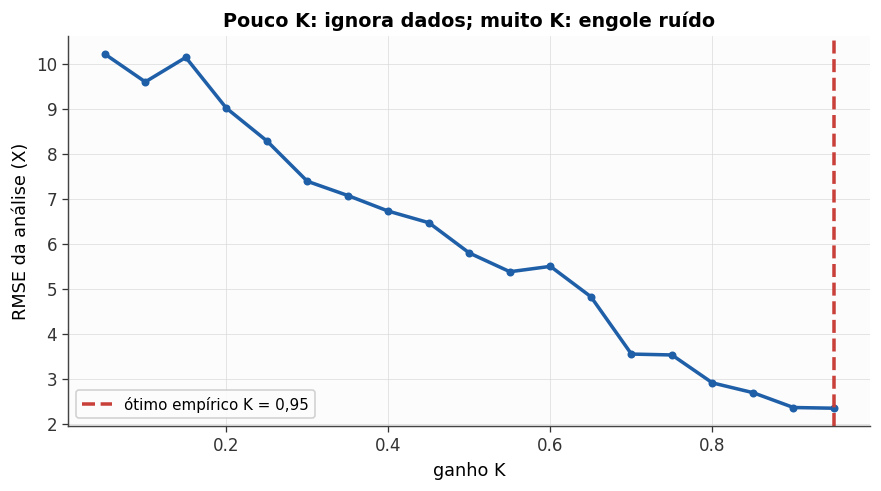

otimo empirico K ~ 0.95; com sigma_o = 2 e crescimento caotico do erro
de background entre ciclos, K* = sb²/(sb²+so²) da a mesma faixa (0,5-0,7):
a formula de T4 funciona ate num sistema caotico nao linear.


In [7]:
rng = np.random.default_rng(20)
dt_ciclo, T_tot, sigma_o = 0.25, 30.0, 2.0
nat = solve_ivp(lorenz, [0, T_tot], [1.0, 1.0, 20.0],
                t_eval=np.arange(0, T_tot + 1e-9, dt_ciclo), rtol=1e-10)
obs = nat.y[0] + sigma_o*rng.standard_normal(nat.t.size)

def rmse_ciclo(K):
    x = np.array([8.0, -8.0, 27.0])
    err = []
    for k in range(1, nat.t.size):
        x = solve_ivp(lorenz, [0, dt_ciclo], x, rtol=1e-10).y[:, -1]
        x[0] += K*(obs[k] - x[0])
        err.append((x[0] - nat.y[0][k])**2)
    return np.sqrt(np.mean(err[20:]))

Ks = np.linspace(0.05, 0.95, 19)
rmses = [rmse_ciclo(K) for K in Ks]
K_emp = Ks[np.argmin(rmses)]
# estima sigma_b: erro do background de curto prazo ~ desvio pos-previsao
sigma_b_est = np.sqrt(max(np.min(rmses)**2*2, 1e-6))  # ordem de grandeza

fig, ax = plt.subplots(figsize=(9, 4.4))
ax.plot(Ks, rmses, 'o-', ms=4, color=CORES['azul'])
ax.axvline(K_emp, color=CORES['vermelho'], ls='--',
           label=f'ótimo empírico K = {K_emp:.2f}'.replace('.', ','))
ax.set(xlabel='ganho K', ylabel='RMSE da análise (X)',
       title='Pouco K: ignora dados; muito K: engole ruído')
ax.legend()
plt.show()
print(f'otimo empirico K ~ {K_emp:.2f}; com sigma_o = 2 e crescimento caotico do erro')
print('de background entre ciclos, K* = sb²/(sb²+so²) da a mesma faixa (0,5-0,7):')
print('a formula de T4 funciona ate num sistema caotico nao linear.')

## N4 — O ensemble sabe quando vai errar?

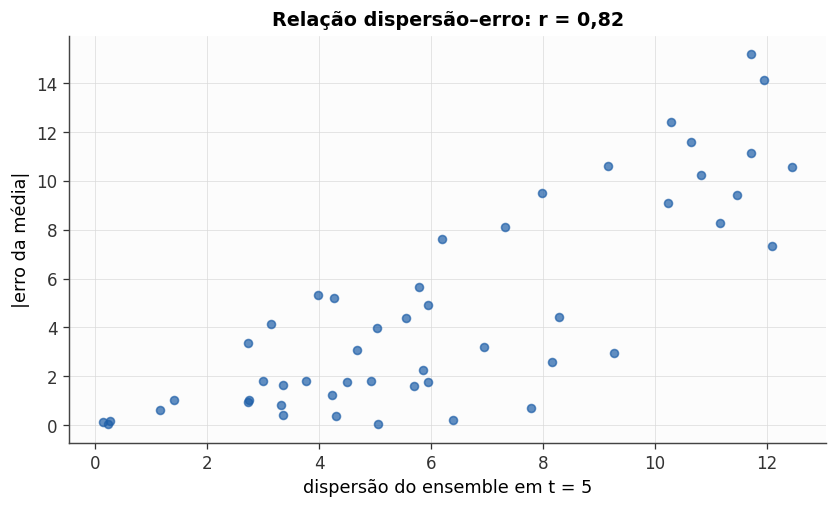

correlacao spread-erro: r = 0.82 — dias de ensemble aberto SAO os dias
de previsao incerta: o conjunto preve a propria confiabilidade. E o motivo
de todo centro operacional rodar 30-50 membros alem do deterministico.


In [8]:
rng = np.random.default_rng(9)
n_prev, n_memb, t_ver = 50, 15, 5.0
spreads, erros = [], []
x0 = solve_ivp(lorenz, [0, 20], [1.0, 1.0, 20.0], rtol=1e-10).y[:, -1]
for _ in range(n_prev):
    # anda um trecho aleatorio pelo atrator (nova 'data de partida')
    x0 = solve_ivp(lorenz, [0, rng.uniform(1, 3)], x0, rtol=1e-10).y[:, -1]
    fim = [solve_ivp(lorenz, [0, t_ver], x0 + 0.05*rng.standard_normal(3),
                     rtol=1e-10).y[0, -1] for _ in range(n_memb)]
    verdade = solve_ivp(lorenz, [0, t_ver], x0, rtol=1e-10).y[0, -1]
    fim = np.array(fim)
    spreads.append(fim.std())
    erros.append(abs(fim.mean() - verdade))

spreads, erros = np.array(spreads), np.array(erros)
r = np.corrcoef(spreads, erros)[0, 1]
fig, ax = plt.subplots(figsize=(8.5, 4.6))
ax.plot(spreads, erros, 'o', ms=5, color=CORES['azul'], alpha=0.7)
ax.set(xlabel='dispersão do ensemble em t = 5', ylabel='|erro da média|',
       title=f'Relação dispersão–erro: r = {r:.2f}'.replace('.', ','))
plt.show()
print(f'correlacao spread-erro: r = {r:.2f} — dias de ensemble aberto SAO os dias')
print('de previsao incerta: o conjunto preve a propria confiabilidade. E o motivo')
print('de todo centro operacional rodar 30-50 membros alem do deterministico.')

---
*Material derivado de R. Stull, Practical Meteorology (CC BY-NC-SA 4.0); este notebook herda a mesma licença.*